# Bylaw Violation Classification
## Notebook 1 — Data Understanding & Exploratory Data Analysis

**Research Question:** Can machine learning classify which residential code complaints will result in a confirmed bylaw violation, so that enforcement teams can triage incoming cases and inspect the highest-risk properties first?

**Dataset:** Austin Code Complaint Cases — [City of Austin Open Data Portal](https://data.austintexas.gov/Public-Safety/Austin-Code-Complaint-Cases/6wtj-zbtb)  
**Target Variable:** `violation_upheld` — whether a complaint results in a confirmed violation (1) or no violation found (0)

This notebook covers data acquisition, cleaning, target construction, feature engineering, and exploratory analysis. **Modeling, cross-validation, hyperparameter tuning, and evaluation are in the companion notebook [`02_modeling.ipynb`](02_modeling.ipynb).**

## 0. Setup — Imports

In [1]:
import os
import warnings
import urllib.request

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay,
    f1_score, roc_auc_score
)
from sklearn.model_selection import train_test_split

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
pd.set_option('display.max_columns', 30)
pd.set_option('display.max_colwidth', 60)

## 1. Data Acquisition

Data is sourced from the City of Austin Open Data Portal. It contains code enforcement complaint cases filed with Austin Code Enforcement, including complaint type, resolution status, dates, location, and inspector information. The dataset is downloaded once and cached locally.

In [2]:
os.makedirs('../data', exist_ok=True)

DATA_PATH = '../data/austin_code_complaints.csv'
URL = 'https://data.austintexas.gov/api/views/6wtj-zbtb/rows.csv?accessType=DOWNLOAD'

if not os.path.exists(DATA_PATH):
    print('Downloading dataset (~83k rows, may take a moment)...')
    urllib.request.urlretrieve(URL, DATA_PATH)
    print(f'Saved to {DATA_PATH}')
else:
    print(f'Data already cached at {DATA_PATH}')

df = pd.read_csv(DATA_PATH, low_memory=False)
df.columns = df.columns.str.lower()  # full CSV export uses uppercase headers
print(f'Shape: {df.shape}')
df.head(3)

Data already cached at ../data/austin_code_complaints.csv
Shape: (82984, 27)


,case_id,priority,status,address_long,house_number,street_name,city,state,zip_code,opened_date,closed_date,department,case_type,description,inspector,date_updated,last_update,violationcasenumber,violationcaselink,parcelid,location,latitude,longitude,repeatoffenderrelated,shorttermrentalrelated,servicerequestnumber,reportedby
0,2025-005905 CC,5.0,Closed,1100 BLAIR WAY,1100,BLAIR WAY,AUSTIN,TX,78704.0,01/16/2025,01/16/2025,Code Enforcement,Complaints,Land Use Violation(s),Roman Lopez|(512) 415-8397,01/16/2025 12:00:00 AM,Inspection Performed/Abated by Inspector,NaN,NaN,0405061501,"(30.23689875, -97.77211841)",30.236899,-97.772118,No,NaN,NaN,COA Department
1,2023-151300 CC,5.0,Closed,1107 CUMBERLAND ROAD,1107,CUMBERLAND RD,AUSTIN,TX,78704.0,11/23/2023,11/27/2023,Code Enforcement,Complaints,Property Abatement,Monroe Yarbrough|512-788-3046,11/27/2023 12:00:00 AM,No Violation(s) Found/Inspection Performed,NaN,NaN,0403050539,"(30.24099532, -97.76957386)",30.240995,-97.769574,No,NaN,23-00522848,Anonymous
2,2023-129349 CC,5.0,Closed,6709 WENTWORTH DRIVE,6709,WENTWORTH DR,AUSTIN,TX,78724.0,10/05/2023,10/11/2023,Code Enforcement,Complaints,Property Abatement,Aaron Janke|(512) 945-8356,10/11/2023 12:00:00 AM,Inspection Performed/Abated by Community Court,NaN,NaN,0217380301,"(30.2938479, -97.63073535)",30.293848,-97.630735,No,NaN,23-00459390,Complainant


## 2. Initial Exploration

In [3]:
# Column names, dtypes, and non-null counts
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 82984 entries, 0 to 82983
Data columns (total 27 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   case_id                 82984 non-null  str    
 1   priority                80433 non-null  float64
 2   status                  82984 non-null  str    
 3   address_long            82932 non-null  str    
 4   house_number            72999 non-null  str    
 5   street_name             73005 non-null  str    
 6   city                    72999 non-null  str    
 7   state                   73001 non-null  str    
 8   zip_code                72628 non-null  float64
 9   opened_date             82984 non-null  str    
 10  closed_date             79599 non-null  str    
 11  department              82984 non-null  str    
 12  case_type               82984 non-null  str    
 13  description             82984 non-null  str    
 14  inspector               82984 non-null  str    
 

In [4]:
# Summary statistics for all columns
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
case_id,82984,82984,2025-005905 CC,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
priority,80433.0,NaN,NaN,NaN,4.014211,1.354117,0.0,2.0,5.0,5.0,90.0
status,82984,3,Closed,79601,NaN,NaN,NaN,NaN,NaN,NaN,NaN
address_long,82932,47403,4807 PROCK LANE,182,NaN,NaN,NaN,NaN,NaN,NaN,NaN
house_number,72999,5499,1700,360,NaN,NaN,NaN,NaN,NaN,NaN,NaN
street_name,73005,5714,N LAMAR BLVD,992,NaN,NaN,NaN,NaN,NaN,NaN,NaN
city,72999,14,AUSTIN,72965,NaN,NaN,NaN,NaN,NaN,NaN,NaN
state,73001,1,TX,73001,NaN,NaN,NaN,NaN,NaN,NaN,NaN
zip_code,72628.0,NaN,NaN,NaN,78733.535978,22.576575,78610.0,78721.0,78741.0,78752.0,78759.0
opened_date,82984,1282,04/22/2025,278,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 3. Data Cleaning

Steps:
1. Identify and visualize missing values
2. Remove duplicate records
3. Parse date columns
4. Standardize text and categorical fields

In [5]:
# Missing value summary
missing = pd.DataFrame({
    'missing_count': df.isnull().sum(),
    'missing_pct': (df.isnull().mean() * 100).round(2)
}).sort_values('missing_pct', ascending=False)

missing[missing.missing_count > 0]

,missing_count,missing_pct
shorttermrentalrelated,79585,95.90
violationcaselink,62753,75.62
violationcasenumber,59348,71.52
parcelid,10856,13.08
zip_code,10356,12.48
latitude,10309,12.42
location,10309,12.42
longitude,10309,12.42
house_number,9985,12.03
street_name,9979,12.03


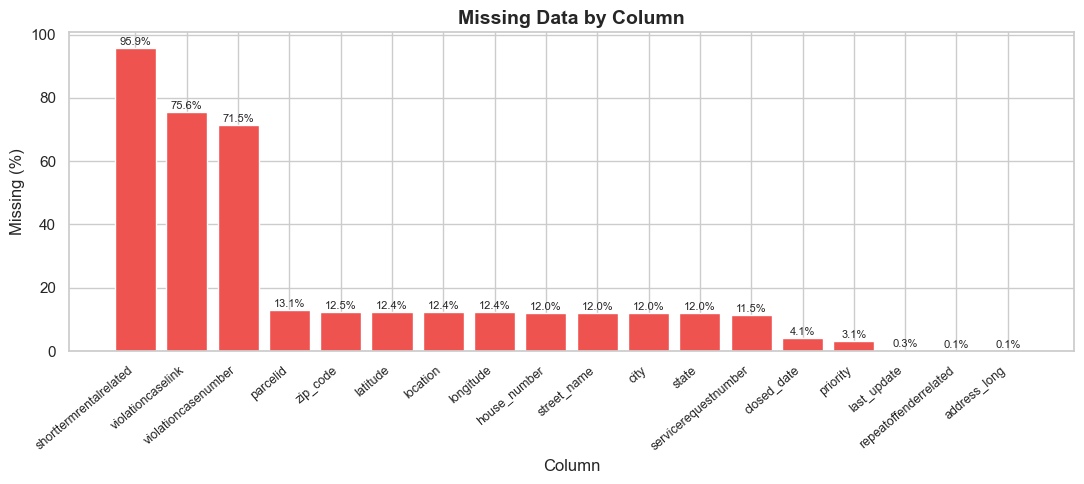

In [6]:
# Visualize missingness by column
miss_plot = missing[missing.missing_pct > 0]

fig, ax = plt.subplots(figsize=(11, 5))
bars = ax.bar(miss_plot.index, miss_plot['missing_pct'],
              color='#EF5350', edgecolor='white', linewidth=1)
ax.set_title('Missing Data by Column', fontsize=14, fontweight='bold')
ax.set_xlabel('Column')
ax.set_ylabel('Missing (%)')
ax.set_xticklabels(miss_plot.index, rotation=40, ha='right', fontsize=9)

for bar, val in zip(bars, miss_plot['missing_pct']):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
            f'{val:.1f}%', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

In [7]:
# Remove duplicate rows
print(f'Duplicate rows before: {df.duplicated().sum()}')
df = df.drop_duplicates()
print(f'Shape after dedup: {df.shape}')

Duplicate rows before: 0
Shape after dedup: (82984, 27)


In [8]:
# Parse dates
for col in ['opened_date', 'closed_date', 'date_updated']:
    df[col] = pd.to_datetime(df[col], errors='coerce')

# Fill missing categoricals with sensible defaults
df['repeatoffenderrelated'] = df['repeatoffenderrelated'].fillna('No')
df['shorttermrentalrelated'] = df['shorttermrentalrelated'].fillna('No')
df['reportedby'] = df['reportedby'].fillna('Unknown')

# Normalize the reporting source: the raw field mixes case
# (e.g. 'Investigator' vs 'investigator', 'Complainant' vs 'complainant').
df['reportedby'] = df['reportedby'].astype(str).str.strip().str.title()

# Standardize the complaint type. The raw 'description' field has a handful of dirty
# rows (repeated phrases, plural variants) on top of four real complaint categories.
def standardize_description(text):
    t = str(text).lower()
    if 'property abatement' in t:
        return 'Property Abatement'
    if 'structure condition' in t:
        return 'Structure Condition Violation'
    if 'land use' in t:
        return 'Land Use Violation'
    if 'work without permit' in t:
        return 'Work Without Permit'
    return 'Other'

df['description'] = df['description'].apply(standardize_description)

# Clean the priority field: valid levels are 1-5 (1 = highest urgency).
# Values such as 0, 9, and 90 are data-entry errors -> set to missing.
df['priority'] = pd.to_numeric(df['priority'], errors='coerce')
df.loc[~df['priority'].isin([1, 2, 3, 4, 5]), 'priority'] = np.nan

# Normalize zip code to a clean 5-digit string
df['zip_code'] = df['zip_code'].astype(str).str.strip().str.split('.').str[0]

print('Cleaning complete.')
print('Complaint types:', df['description'].value_counts().to_dict())
df[['opened_date', 'closed_date', 'description', 'status', 'last_update']].head(5)

Cleaning complete.
Complaint types: {'Property Abatement': 36335, 'Structure Condition Violation': 21969, 'Land Use Violation': 21599, 'Work Without Permit': 3080, 'Other': 1}


,opened_date,closed_date,description,status,last_update
0,2025-01-16,2025-01-16,Land Use Violation,Closed,Inspection Performed/Abated by Inspector
1,2023-11-23,2023-11-27,Property Abatement,Closed,No Violation(s) Found/Inspection Performed
2,2023-10-05,2023-10-11,Property Abatement,Closed,Inspection Performed/Abated by Community Court
3,2026-02-20,2026-02-20,Land Use Violation,Closed,Closed/Duplicate Case
4,2025-11-15,2025-11-18,Structure Condition Violation,Closed,Supervisor Review


## 4. Target Variable Engineering

The `last_update` column records how a case was resolved. We derive a binary classification target:

| `violation_upheld` | `last_update` values | Meaning |
|---|---|---|
| `1` | Abated, Voluntary Compliance, Legal Action, Abatement | A violation was confirmed and corrected |
| `0` | No Violation(s) Found | Inspection found no violation |
| excluded | Duplicate, Referred, Cancelled, Follow-up, etc. | Administrative — no substantive outcome |

"Voluntary Compliance" is classified as 1 because it indicates an inspector found an issue that the property owner then corrected — confirming a real violation existed.

In [9]:
# Inspect all unique resolution outcomes
print(df['last_update'].value_counts(dropna=False).head(25).to_string())

last_update
No Violation(s) Found/Inspection Performed        33532
Closed due to Voluntary Compliance                16862
Closed/Duplicate Case                             11475
Inspection Performed/Abated by Inspector           4878
Referred to Appropriate Agency                     4266
Closed due to Abatement                            2134
Follow-up Inspection                               1771
Inspection Performed/Abated by Community Court     1303
Cancelled                                          1002
Legal Action-All Deficiencies Satisfied             990
Inspection Performed/ Voluntary Compliance          946
Contact Performed                                   875
Inspection Performed                                499
Send CV Notice                                      499
Information Update                                  483
Supervisor Review                                   310
NaN                                                 231
Code Connect Contact                

In [10]:
def encode_outcome(text):
    """Map resolution text to binary label. Returns NaN for administrative closures."""
    if pd.isna(text):
        return np.nan
    t = text.lower()
    if 'no violation' in t:
        return 0
    # Voluntary compliance = inspector found an issue; owner corrected it without citation
    # Abatement, legal action, and direct enforcement are all confirmed violations
    if any(kw in t for kw in ['abated', 'abatement', 'voluntary compliance',
                               'citation issued', 'legal action']):
        return 1
    return np.nan

# Apply only to closed cases with known outcomes
df['violation_upheld'] = df['last_update'].apply(encode_outcome)

counts = df['violation_upheld'].value_counts(dropna=False)
print(counts)
print(f'\nRows with a defined target: {df["violation_upheld"].notna().sum():,}')
print(f'Rows excluded (admin closures / open): {df["violation_upheld"].isna().sum():,}')

violation_upheld
0.0    33558
1.0    27114
NaN    22312
Name: count, dtype: int64

Rows with a defined target: 60,672
Rows excluded (admin closures / open): 22,312


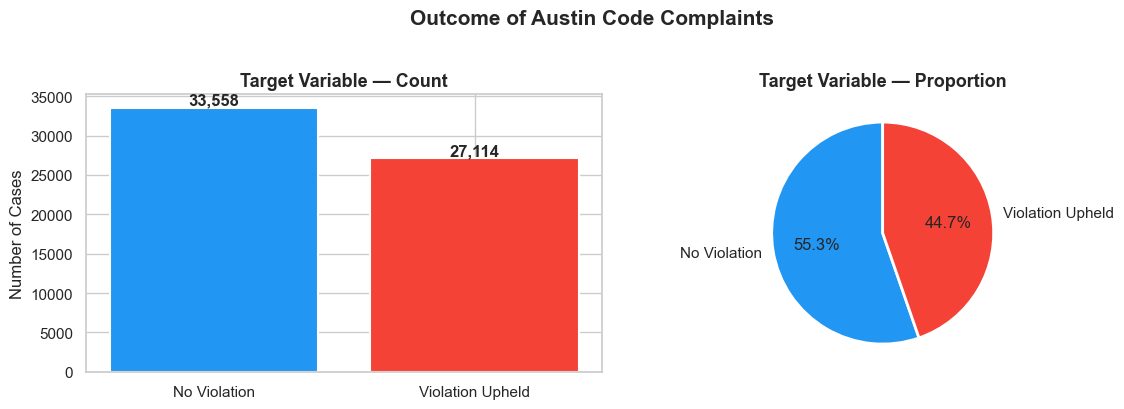

In [11]:
target_data = df['violation_upheld'].dropna()
labels = {0.0: 'No Violation', 1.0: 'Violation Upheld'}
counts = target_data.value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart
bars = axes[0].bar(
    [labels[i] for i in counts.index], counts.values,
    color=['#2196F3', '#F44336'], edgecolor='white', linewidth=1.5
)
axes[0].set_title('Target Variable — Count', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Number of Cases')
for bar, val in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 40,
                 f'{val:,}', ha='center', va='bottom', fontweight='bold')

# Pie chart
axes[1].pie(
    counts.values,
    labels=[labels[i] for i in counts.index],
    autopct='%1.1f%%',
    colors=['#2196F3', '#F44336'],
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
axes[1].set_title('Target Variable — Proportion', fontsize=13, fontweight='bold')

plt.suptitle('Outcome of Austin Code Complaints', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 5. Feature Engineering

We extract and transform variables from the raw data for use in modeling:

| Feature | Source | Description |
|---|---|---|
| `days_to_close` | `closed_date - opened_date` | Enforcement response time |
| `opened_month` | `opened_date` | Filing month (1–12) |
| `opened_dayofweek` | `opened_date` | Filing day of week (0=Mon) |
| `opened_year` | `opened_date` | Filing year |
| `is_repeat_offender` | `repeatoffenderrelated` | 1 if flagged repeat offender |
| `is_short_term_rental` | `shorttermrentalrelated` | 1 if short-term rental involved |

In [12]:
# Build modeling dataset from closed cases with a defined outcome
df_model = df[df['violation_upheld'].notna()].copy()

# Temporal features
df_model['opened_month'] = df_model['opened_date'].dt.month
df_model['opened_dayofweek'] = df_model['opened_date'].dt.dayofweek
df_model['opened_year'] = df_model['opened_date'].dt.year

# Days to resolve the complaint
df_model['days_to_close'] = (
    df_model['closed_date'] - df_model['opened_date']
).dt.days

# Boolean flags → integer
df_model['is_repeat_offender'] = (df_model['repeatoffenderrelated'] == 'Yes').astype(int)
df_model['is_short_term_rental'] = (df_model['shorttermrentalrelated'] == 'Yes').astype(int)

# Priority as numeric
df_model['priority'] = pd.to_numeric(df_model['priority'], errors='coerce')

print(f'Modeling dataset shape: {df_model.shape}')
df_model[['priority', 'days_to_close', 'opened_month', 'opened_dayofweek',
          'is_repeat_offender', 'is_short_term_rental', 'violation_upheld']].head()

Modeling dataset shape: (60672, 34)


,priority,days_to_close,opened_month,opened_dayofweek,is_repeat_offender,is_short_term_rental,violation_upheld
0,5.0,0.0,1,3,0,0,1.0
1,5.0,4.0,11,3,0,0,0.0
2,5.0,6.0,10,3,0,0,1.0
5,5.0,4.0,3,3,0,0,1.0
7,5.0,0.0,4,1,0,0,0.0


## 6. Exploratory Data Analysis
### 6.1 Univariate Analysis

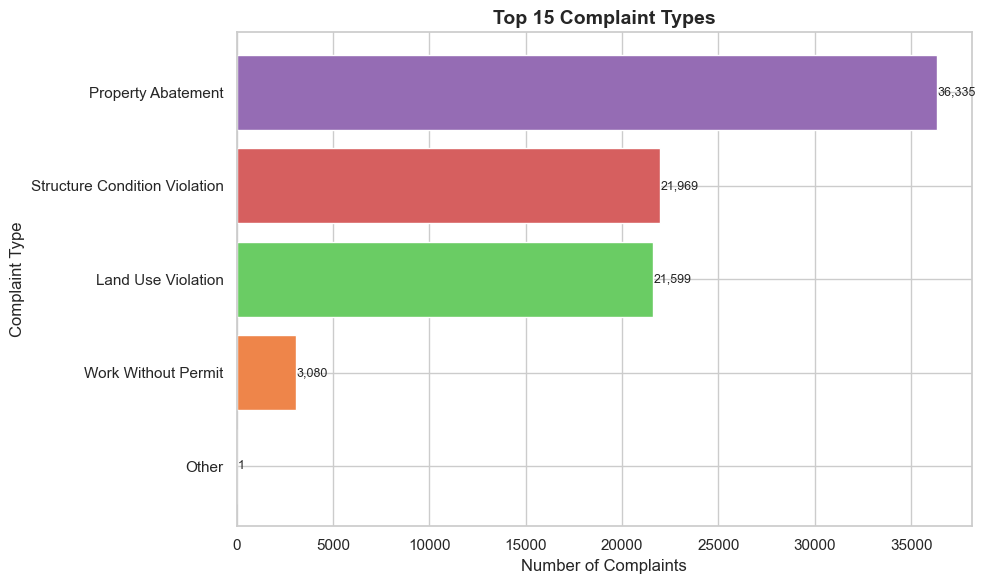

In [13]:
# Top 15 complaint types
top_types = df['description'].value_counts().head(15)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(
    top_types.index[::-1], top_types.values[::-1],
    color=sns.color_palette('muted', 15)
)
ax.set_title('Top 15 Complaint Types', fontsize=14, fontweight='bold')
ax.set_xlabel('Number of Complaints')
ax.set_ylabel('Complaint Type')
for bar, val in zip(bars, top_types.values[::-1]):
    ax.text(bar.get_width() + 30, bar.get_y() + bar.get_height() / 2,
            f'{val:,}', va='center', fontsize=9)
plt.tight_layout()
plt.show()

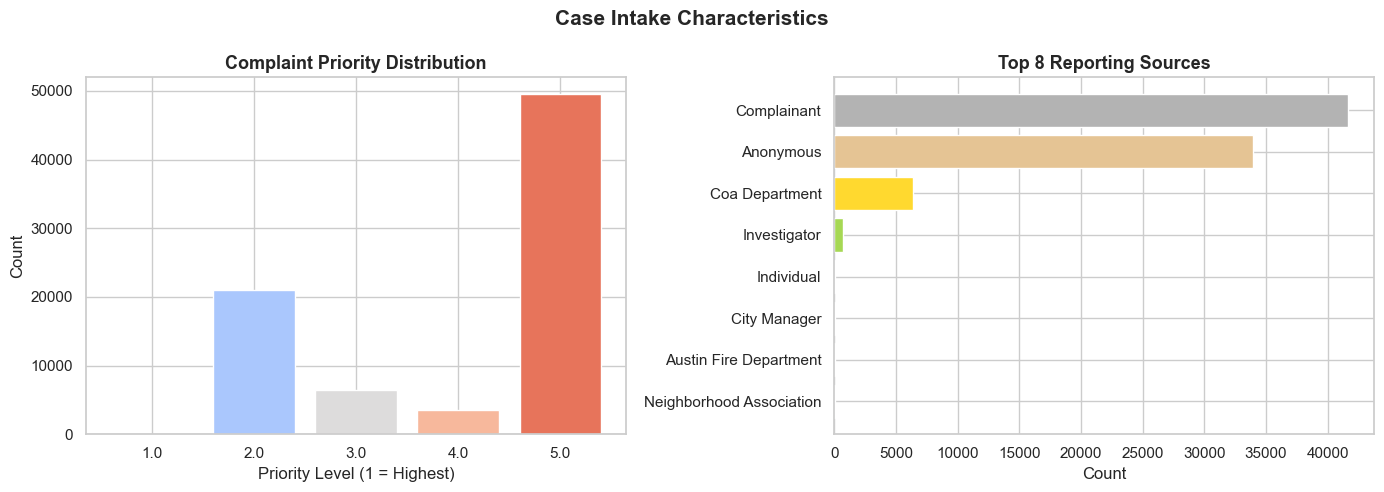

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Priority distribution
priority_counts = df['priority'].value_counts().sort_index()
axes[0].bar(
    priority_counts.index.astype(str), priority_counts.values,
    color=sns.color_palette('coolwarm', len(priority_counts))
)
axes[0].set_title('Complaint Priority Distribution', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Priority Level (1 = Highest)')
axes[0].set_ylabel('Count')

# Reporting source
reported = df['reportedby'].value_counts().head(8)
axes[1].barh(
    reported.index[::-1], reported.values[::-1],
    color=sns.color_palette('Set2', 8)
)
axes[1].set_title('Top 8 Reporting Sources', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Count')

plt.suptitle('Case Intake Characteristics', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

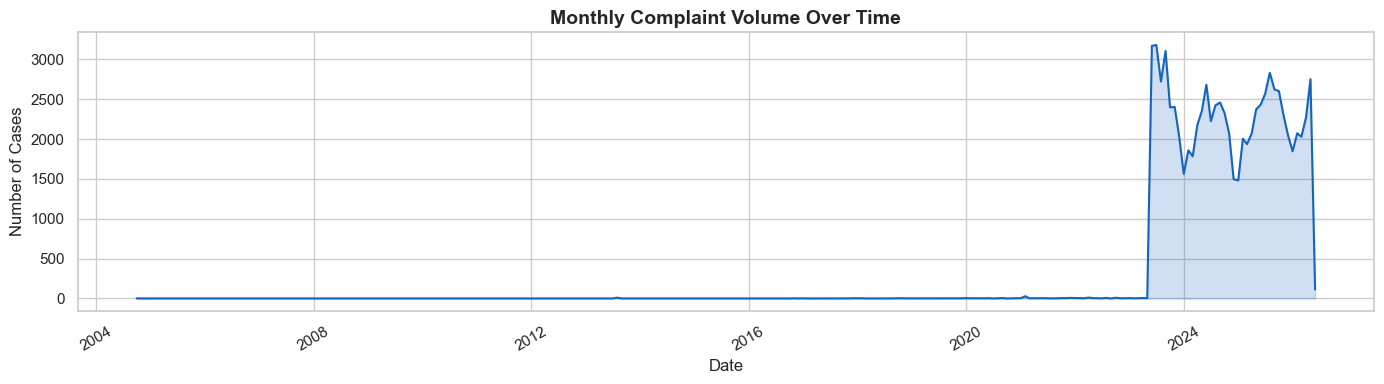

In [15]:
# Monthly complaint volume over time
monthly = (
    df.set_index('opened_date')
      .resample('ME')
      .size()
      .rename('cases')
)

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(monthly.index, monthly.values, linewidth=1.5, color='#1565C0')
ax.fill_between(monthly.index, monthly.values, alpha=0.2, color='#1565C0')
ax.set_title('Monthly Complaint Volume Over Time', fontsize=14, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Number of Cases')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

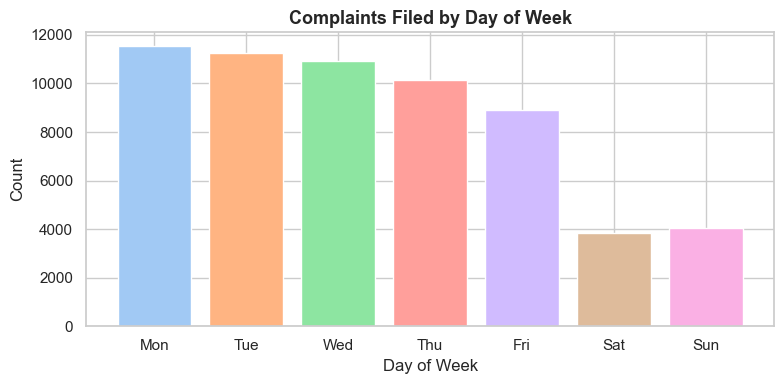

In [16]:
# Cases by day of week
day_names = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
dow_counts = df_model['opened_dayofweek'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(
    [day_names[i] for i in dow_counts.index],
    dow_counts.values,
    color=sns.color_palette('pastel', 7)
)
ax.set_title('Complaints Filed by Day of Week', fontsize=13, fontweight='bold')
ax.set_xlabel('Day of Week')
ax.set_ylabel('Count')
plt.tight_layout()
plt.show()

### 6.2 Bivariate Analysis — Outcome vs Features

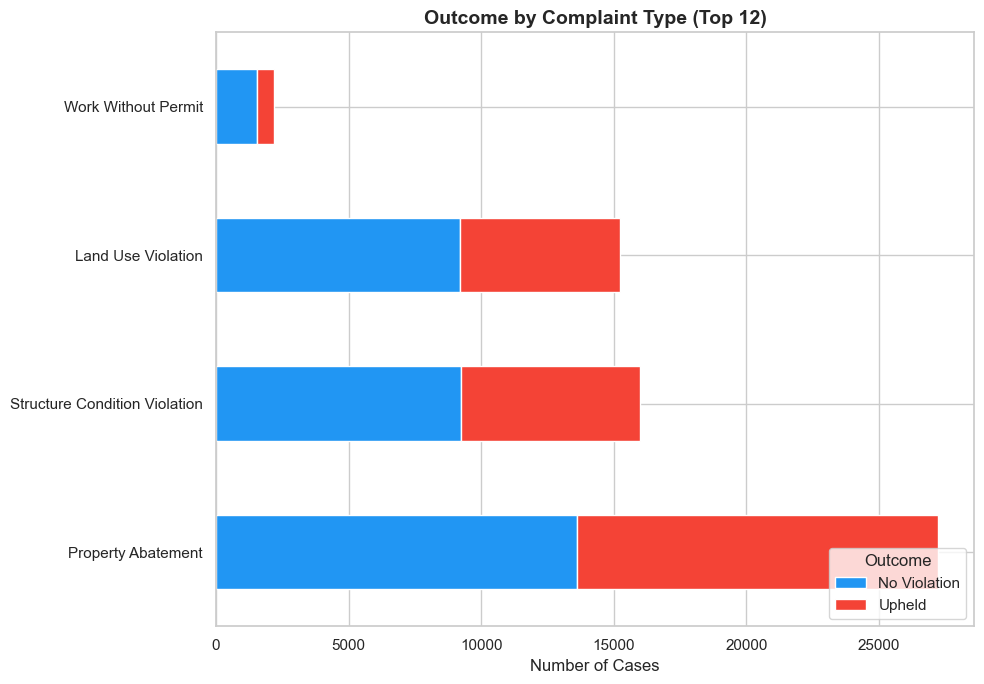

In [17]:
# Stacked bar: outcome by complaint type (top 12)
type_outcome = (
    df_model
    .groupby(['description', 'violation_upheld'])
    .size()
    .unstack(fill_value=0)
)
type_outcome.columns = ['No Violation', 'Upheld']
type_outcome['total'] = type_outcome.sum(axis=1)
top12 = type_outcome.nlargest(12, 'total')

fig, ax = plt.subplots(figsize=(10, 7))
top12[['No Violation', 'Upheld']].plot(
    kind='barh', stacked=True, ax=ax,
    color=['#2196F3', '#F44336']
)
ax.set_title('Outcome by Complaint Type (Top 12)', fontsize=14, fontweight='bold')
ax.set_xlabel('Number of Cases')
ax.set_ylabel('')
ax.legend(title='Outcome', loc='lower right')
plt.tight_layout()
plt.show()

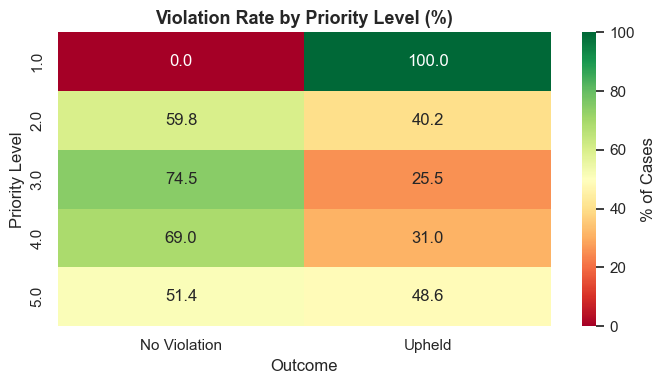

In [18]:
# Heatmap: violation rate by priority level
priority_outcome = (
    df_model
    .groupby(['priority', 'violation_upheld'])
    .size()
    .unstack(fill_value=0)
)
priority_outcome.columns = ['No Violation', 'Upheld']
rate_pct = priority_outcome.div(priority_outcome.sum(axis=1), axis=0).mul(100).round(1)

fig, ax = plt.subplots(figsize=(7, 4))
sns.heatmap(
    rate_pct, annot=True, fmt='.1f', cmap='RdYlGn',
    cbar_kws={'label': '% of Cases'}, ax=ax
)
ax.set_title('Violation Rate by Priority Level (%)', fontsize=13, fontweight='bold')
ax.set_xlabel('Outcome')
ax.set_ylabel('Priority Level')
plt.tight_layout()
plt.show()

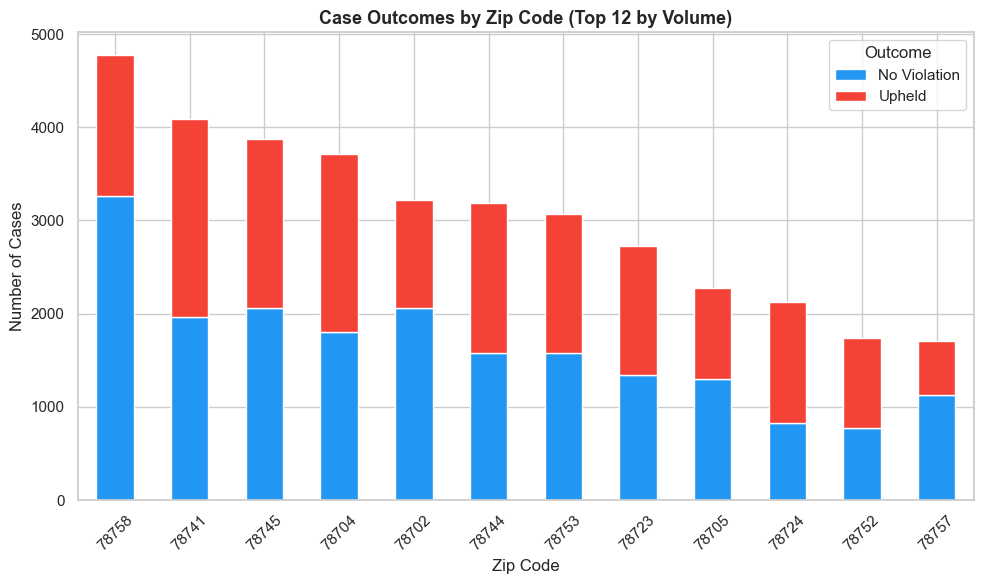

In [19]:
# Outcome by top zip codes
zip_outcome = (
    df_model
    .groupby(['zip_code', 'violation_upheld'])
    .size()
    .unstack(fill_value=0)
)
zip_outcome.columns = ['No Violation', 'Upheld']
zip_outcome['total'] = zip_outcome.sum(axis=1)
top_zips = zip_outcome.nlargest(12, 'total')

fig, ax = plt.subplots(figsize=(10, 6))
top_zips[['No Violation', 'Upheld']].plot(
    kind='bar', stacked=True, ax=ax,
    color=['#2196F3', '#F44336']
)
ax.set_title('Case Outcomes by Zip Code (Top 12 by Volume)', fontsize=13, fontweight='bold')
ax.set_xlabel('Zip Code')
ax.set_ylabel('Number of Cases')
ax.legend(title='Outcome')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

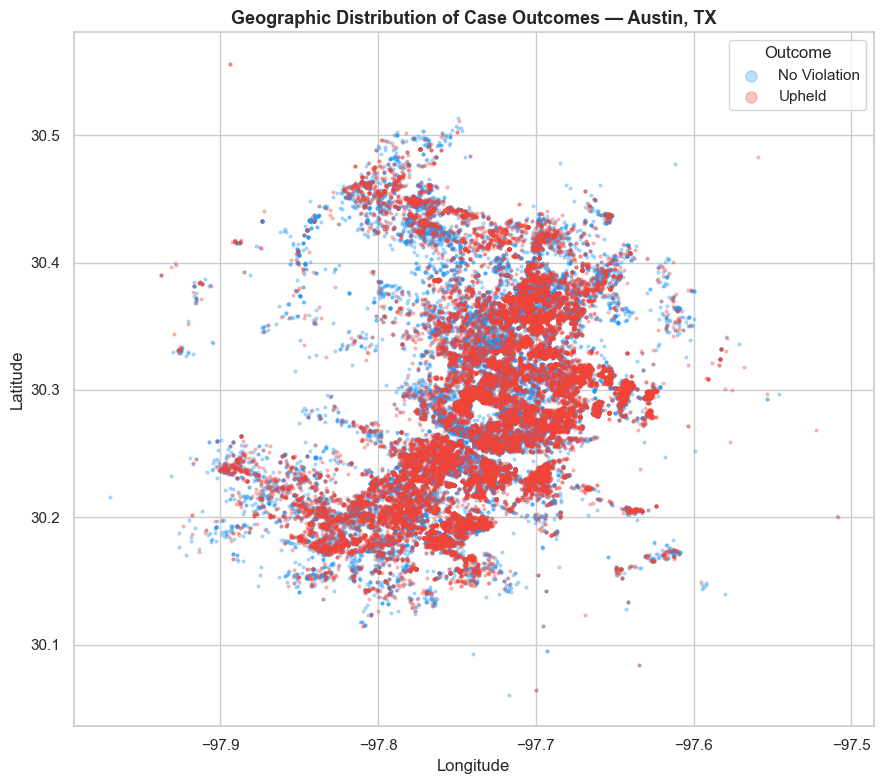

In [20]:
# Geographic scatter plot
geo = df_model.copy()
geo['latitude'] = pd.to_numeric(geo['latitude'], errors='coerce')
geo['longitude'] = pd.to_numeric(geo['longitude'], errors='coerce')
geo = geo.dropna(subset=['latitude', 'longitude'])

fig, ax = plt.subplots(figsize=(9, 8))
for outcome, color, label in [(0, '#2196F3', 'No Violation'), (1, '#F44336', 'Upheld')]:
    grp = geo[geo['violation_upheld'] == outcome]
    ax.scatter(grp['longitude'], grp['latitude'],
               c=color, label=label, alpha=0.3, s=4)

ax.set_title('Geographic Distribution of Case Outcomes — Austin, TX',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.legend(title='Outcome', markerscale=4, fontsize=11)
plt.tight_layout()
plt.show()

## 7. Outlier Analysis

We use the IQR method to detect and handle outliers in numeric features. The key engineered feature `days_to_close` is especially prone to extreme values from long-pending or mis-dated cases.

In [21]:
dtc = df_model['days_to_close'].dropna()

Q1 = dtc.quantile(0.25)
Q3 = dtc.quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = dtc[(dtc < lower_bound) | (dtc > upper_bound)]
print(f'Q1={Q1:.1f}  Q3={Q3:.1f}  IQR={IQR:.1f}')
print(f'Outlier bounds: [{lower_bound:.1f}, {upper_bound:.1f}]')
print(f'Outlier count: {len(outliers):,} ({len(outliers)/len(dtc)*100:.1f}% of cases)')
print(f'Max days to close: {dtc.max()}')

Q1=1.0  Q3=26.0  IQR=25.0
Outlier bounds: [-36.5, 63.5]
Outlier count: 6,650 (11.0% of cases)
Max days to close: 1009.0


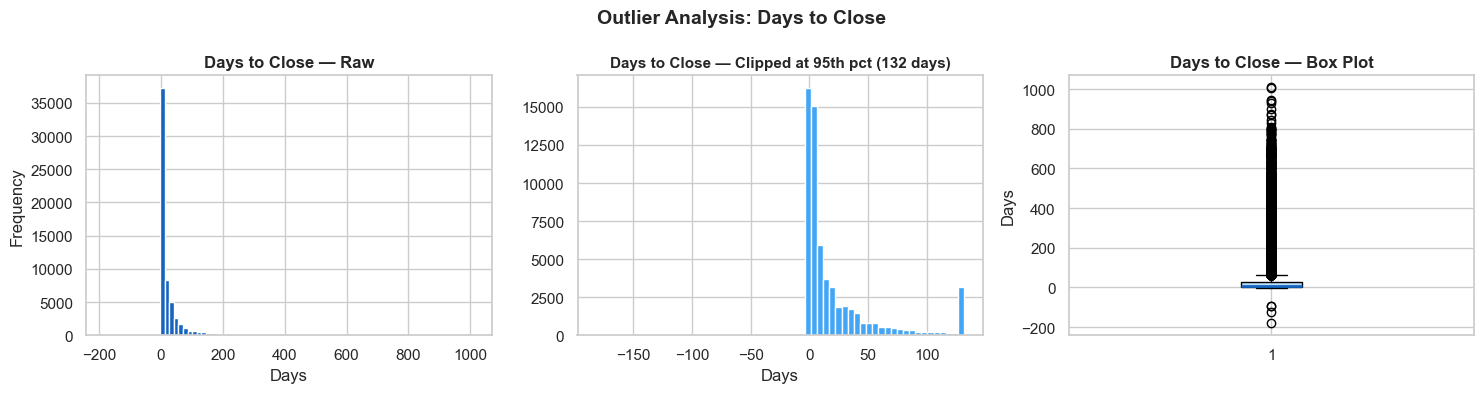

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Raw distribution
axes[0].hist(dtc, bins=80, color='#1565C0', edgecolor='white')
axes[0].set_title('Days to Close — Raw', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Days')
axes[0].set_ylabel('Frequency')

# Clipped at 95th percentile for readability
clip_val = dtc.quantile(0.95)
axes[1].hist(dtc.clip(upper=clip_val), bins=60, color='#42A5F5', edgecolor='white')
axes[1].set_title(f'Days to Close — Clipped at 95th pct ({clip_val:.0f} days)',
                  fontsize=11, fontweight='bold')
axes[1].set_xlabel('Days')

# Box plot
axes[2].boxplot(dtc, patch_artist=True,
                boxprops={'facecolor': '#BBDEFB'},
                medianprops={'color': '#1565C0', 'linewidth': 2})
axes[2].set_title('Days to Close — Box Plot', fontsize=12, fontweight='bold')
axes[2].set_ylabel('Days')

plt.suptitle('Outlier Analysis: Days to Close', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Cap outliers at IQR upper bound for modeling
df_model['days_to_close_capped'] = df_model['days_to_close'].clip(
    lower=max(0, lower_bound), upper=upper_bound
)

## 8. Complaint Type vs. Outcome

The `description` field is a **categorical** complaint type with four real categories (Property Abatement, Structure Condition, Land Use, Work Without Permit) — not free text. Rather than apply NLP, we treat it as a category and examine how the **confirmed-violation rate** differs across complaint types and reporting sources. These differences are exactly the kind of signal a classifier can exploit.

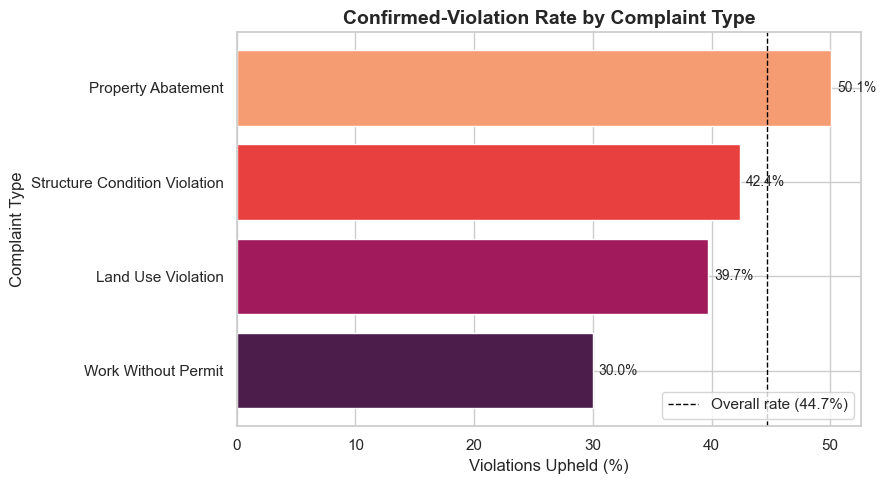

In [23]:
# Confirmed-violation rate by complaint type
type_rate = (
    df_model.groupby('description')['violation_upheld']
    .agg(['count', 'mean'])
    .sort_values('count', ascending=False)
)
type_rate['rate_pct'] = (type_rate['mean'] * 100).round(1)

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(type_rate.index[::-1], type_rate['rate_pct'][::-1],
               color=sns.color_palette('rocket', len(type_rate)))
ax.axvline(df_model['violation_upheld'].mean() * 100, color='black',
           linestyle='--', linewidth=1, label='Overall rate (44.7%)')
ax.set_title('Confirmed-Violation Rate by Complaint Type', fontsize=14, fontweight='bold')
ax.set_xlabel('Violations Upheld (%)')
ax.set_ylabel('Complaint Type')
for bar, val in zip(bars, type_rate['rate_pct'][::-1]):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height() / 2,
            f'{val:.1f}%', va='center', fontsize=10)
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

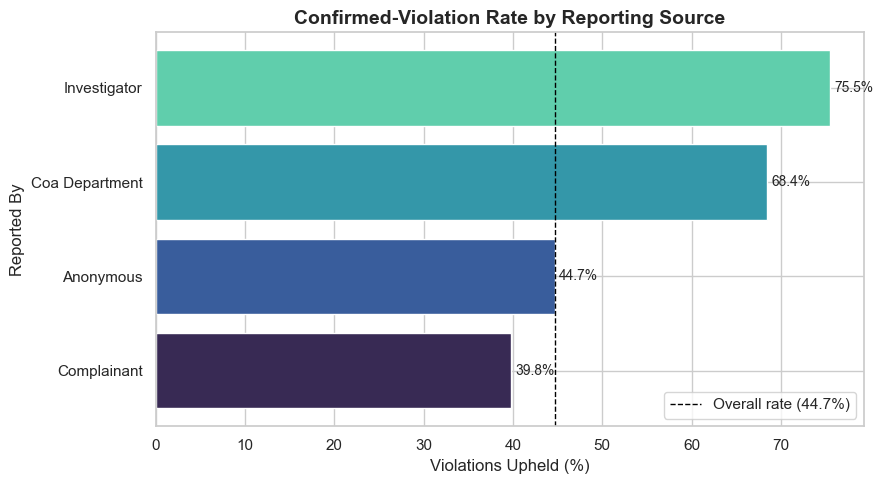

In [24]:
# Confirmed-violation rate by reporting source (top sources by volume)
src = (
    df_model.groupby('reportedby')['violation_upheld']
    .agg(['count', 'mean'])
)
src = src[src['count'] >= 200].sort_values('mean', ascending=False)
src['rate_pct'] = (src['mean'] * 100).round(1)

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(src.index[::-1], src['rate_pct'][::-1],
               color=sns.color_palette('mako', len(src)))
ax.axvline(df_model['violation_upheld'].mean() * 100, color='black',
           linestyle='--', linewidth=1, label='Overall rate (44.7%)')
ax.set_title('Confirmed-Violation Rate by Reporting Source',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Violations Upheld (%)')
ax.set_ylabel('Reported By')
for bar, val in zip(bars, src['rate_pct'][::-1]):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height() / 2,
            f'{val:.1f}%', va='center', fontsize=10)
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

## 9. Summary of EDA Findings

### Key patterns

- **Most common complaint type:** Property Abatement (36,334 cases), followed by Structure Condition Violations (21,966) and Land Use Violations (21,598).
- **Complaint type strongly signals outcome:** confirmed-violation rate ranges from **50.1%** (Property Abatement) down to **30.0%** (Work Without Permit) — versus a 44.7% overall rate.
- **Repeat offenders:** 58.9% violation rate vs. 43.5% for first-time complaints — a meaningful predictive signal.
- **Geographic hotspots:** ZIP codes 78758, 78741, 78745, 78704, and 78702 have the highest complaint volumes.
- **Temporal patterns:** complaints spike Monday–Wednesday and drop sharply on weekends — intake is business-hours driven.

### Data quality

- No duplicate records remained after de-duplication.
- Missing values were concentrated in `closed_date` (still-open cases), `violationcasenumber` (no formal case opened), and a small share of location fields.
- `priority` contained data-entry errors (0, 9, 90) that were set to missing; `reportedby` and `description` were standardized to clean categories.

### Target variable

60,672 cases have a defined outcome: **55.3% No Violation, 44.7% Violation Upheld** — well-balanced for binary classification. Administrative closures (duplicates, withdrawn, referred, supervisor review) are excluded because they carry no inspection verdict.

### A note on data leakage

`days_to_close` is informative but is **only known after a case is resolved**. Because our goal is to triage cases *at intake*, using it would leak the future into the model. It is explored here for descriptive purposes but is **excluded from the modeling features** in `02_modeling.ipynb`.

### Next step

Continue to **[`02_modeling.ipynb`](02_modeling.ipynb)**, where we build and compare multiple classifiers with cross-validation and hyperparameter tuning.